# 16×16 Ising magnetization from spin configurations

This notebook computes magnetization directly from the saved spins, without using the simulator's magnetization columns. For each configuration,

$$m = \frac{1}{L^2}\sum_{i=1}^{L^2} s_i, \qquad |m| = \left|m\right|.$$

The ten configurations at each temperature are averaged within each seed first. The plotted error bar is then the standard error across the 1,000 independent seed means. This keeps the independent simulation seed—not an individual bin—as the unit of replication.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

L = 16
N_SITES = L ** 2
EXPECTED_RUNS = 1_000
EXPECTED_TEMPERATURES = 31
BINS_PER_TEMPERATURE = 10

# This notebook lives in notebooks/ising/. Run it from any working directory.
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1]]
REPO_ROOT = next(root for root in candidate_roots if (root / 'data' / 'raw').exists())
DATA_ROOT = REPO_ROOT / 'data' / 'raw'
OUTPUT_ROOT = REPO_ROOT / 'data' / 'processed'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

REPO_ROOT

PosixPath('/data/lledson/senior thesis')

## Discover and validate the simulation runs

Each run contains one 256-column spin file and a bin file whose temperature rows have the same ordering.

In [2]:
run_dirs = sorted(
    DATA_ROOT.glob('ising16_tc_[0-9]*'),
    key=lambda path: int(path.name.rsplit('_', 1)[1]),
)

assert len(run_dirs) == EXPECTED_RUNS, (
    f'Expected {EXPECTED_RUNS} runs, found {len(run_dirs)} under {DATA_ROOT}'
)

print(f'Found {len(run_dirs):,} independent runs')
print(f'Seed range: {100000:,}–{100000 + len(run_dirs) - 1:,}')

Found 1,000 independent runs
Seed range: 100,000–100,999


## Calculate magnetization from the spins

The spin file has one configuration per row. We sum its 256 values and divide by $16^2$. Both signed $m$ and absolute $|m|$ are retained; $|m|$ is used for the transition curve because finite Ising systems switch between the two symmetry-related magnetized states.

In [3]:
seed_mean_abs_m = np.empty((EXPECTED_RUNS, EXPECTED_TEMPERATURES), dtype=np.float64)
seed_mean_signed_m = np.empty_like(seed_mean_abs_m)
temperatures = None

for run_index, run_dir in enumerate(run_dirs):
    suffix = run_dir.name
    spin_file = run_dir / f'spinConfigs_{suffix}.txt'
    bin_file = run_dir / f'bins_{suffix}.txt'

    spins = np.loadtxt(spin_file, dtype=np.int8)
    row_temperatures = np.loadtxt(bin_file, comments='#', usecols=1)

    expected_rows = EXPECTED_TEMPERATURES * BINS_PER_TEMPERATURE
    if spins.shape != (expected_rows, N_SITES):
        raise ValueError(f'{spin_file}: expected {(expected_rows, N_SITES)}, got {spins.shape}')
    if row_temperatures.shape != (expected_rows,):
        raise ValueError(f'{bin_file}: expected {expected_rows} temperatures')
    if not np.isin(spins, (-1, 1)).all():
        raise ValueError(f'{spin_file}: found values other than -1 and +1')

    temperature_grid = row_temperatures.reshape(
        EXPECTED_TEMPERATURES, BINS_PER_TEMPERATURE
    )
    if not np.all(temperature_grid == temperature_grid[:, :1]):
        raise ValueError(f'{bin_file}: bins are not grouped consistently by temperature')
    this_temperatures = temperature_grid[:, 0]

    if temperatures is None:
        temperatures = this_temperatures
    elif not np.array_equal(temperatures, this_temperatures):
        raise ValueError(f'{bin_file}: temperature grid differs from the first run')

    # This is the requested direct calculation: sum all spins and divide by L^2.
    signed_m = spins.sum(axis=1, dtype=np.int32) / N_SITES
    signed_m = signed_m.reshape(EXPECTED_TEMPERATURES, BINS_PER_TEMPERATURE)

    seed_mean_signed_m[run_index] = signed_m.mean(axis=1)
    seed_mean_abs_m[run_index] = np.abs(signed_m).mean(axis=1)

    if (run_index + 1) % 100 == 0:
        print(f'Loaded {run_index + 1:,}/{EXPECTED_RUNS:,} runs')

print(f'Loaded {EXPECTED_RUNS * EXPECTED_TEMPERATURES * BINS_PER_TEMPERATURE:,} configurations')

Loaded 100/1,000 runs


Loaded 200/1,000 runs


Loaded 300/1,000 runs


Loaded 400/1,000 runs


Loaded 500/1,000 runs


Loaded 600/1,000 runs


Loaded 700/1,000 runs


Loaded 800/1,000 runs


Loaded 900/1,000 runs


Loaded 1,000/1,000 runs
Loaded 310,000 configurations


## Average over independent seeds

For each temperature, the standard error is $s/\sqrt{N_{\mathrm{seeds}}}$, where $s$ is the sample standard deviation of the 1,000 per-seed averages.

In [4]:
n_seeds = seed_mean_abs_m.shape[0]
mean_abs_m = seed_mean_abs_m.mean(axis=0)
sem_abs_m = seed_mean_abs_m.std(axis=0, ddof=1) / np.sqrt(n_seeds)
mean_signed_m = seed_mean_signed_m.mean(axis=0)
sem_signed_m = seed_mean_signed_m.std(axis=0, ddof=1) / np.sqrt(n_seeds)

summary = pd.DataFrame({
    'temperature': temperatures,
    'mean_abs_magnetization': mean_abs_m,
    'sem_abs_magnetization': sem_abs_m,
    'mean_signed_magnetization': mean_signed_m,
    'sem_signed_magnetization': sem_signed_m,
    'n_seeds': n_seeds,
    'bins_per_seed': BINS_PER_TEMPERATURE,
})

summary

,temperature,mean_abs_magnetization,sem_abs_magnetization,mean_signed_magnetization,sem_signed_magnetization,n_seeds,bins_per_seed
0,1.50,0.986602,0.000126,0.008472,0.009685,1000,10
1,1.60,0.979672,0.000169,0.003847,0.009533,1000,10
2,1.70,0.970178,0.000221,-0.007633,0.009849,1000,10
3,1.80,0.957123,0.000279,-0.000099,0.009563,1000,10
4,1.90,0.938317,0.000394,-0.001886,0.009163,1000,10
5,2.00,0.911761,0.000553,-0.004244,0.008837,1000,10
6,2.05,0.892266,0.000693,-0.005902,0.008889,1000,10
7,2.10,0.867897,0.000894,-0.011431,0.008655,1000,10
8,2.15,0.836354,0.001126,-0.002218,0.008555,1000,10
9,2.18,0.811334,0.001332,-0.009189,0.008288,1000,10


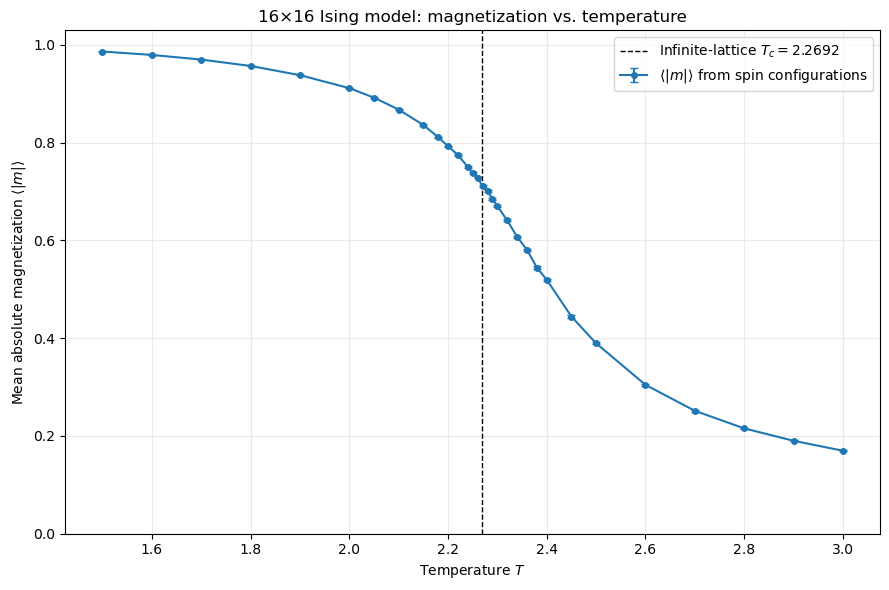

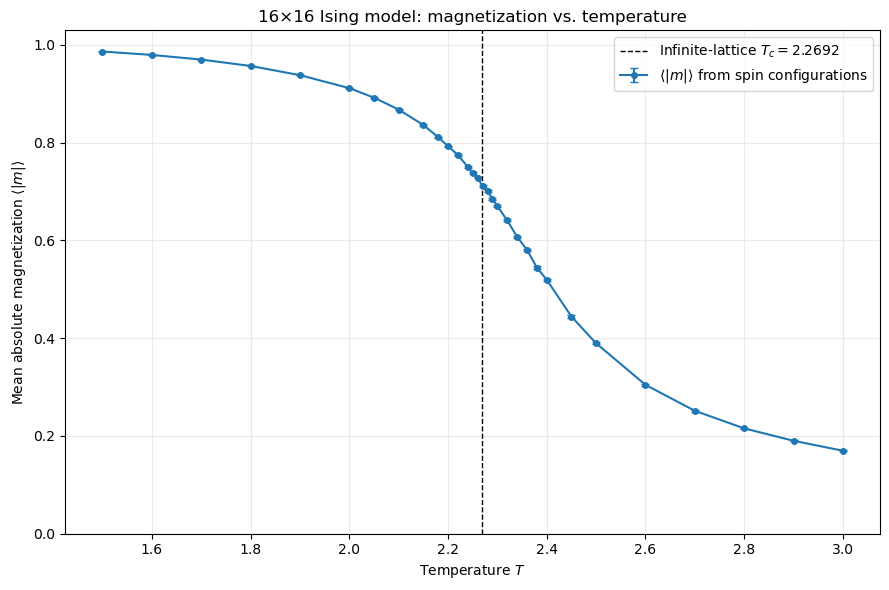

In [5]:
critical_temperature = 2.0 / np.log(1.0 + np.sqrt(2.0))

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(
    summary['temperature'],
    summary['mean_abs_magnetization'],
    yerr=summary['sem_abs_magnetization'],
    fmt='o-',
    markersize=4,
    linewidth=1.5,
    capsize=3,
    label=r'$\langle |m| \rangle$ from spin configurations',
)
ax.axvline(
    critical_temperature,
    color='black',
    linestyle='--',
    linewidth=1,
    label=fr'Infinite-lattice $T_c = {critical_temperature:.4f}$',
)
ax.set(
    xlabel='Temperature $T$',
    ylabel=r'Mean absolute magnetization $\langle |m| \rangle$',
    title='16×16 Ising model: magnetization vs. temperature',
)
ax.set_ylim(0, 1.03)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig

## Save reusable results

The raw simulation outputs remain untouched. The compact summary and publication-resolution plot are written under the ignored `data/processed/` directory.

In [6]:
csv_path = OUTPUT_ROOT / 'ising16_magnetization_summary.csv'
figure_path = OUTPUT_ROOT / 'ising16_magnetization_vs_temperature.png'

summary.to_csv(csv_path, index=False)
fig.savefig(figure_path, dpi=300, bbox_inches='tight')

print(f'Saved {csv_path}')
print(f'Saved {figure_path}')

Saved /data/lledson/senior thesis/data/processed/ising16_magnetization_summary.csv
Saved /data/lledson/senior thesis/data/processed/ising16_magnetization_vs_temperature.png
